In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score,
    recall_score, confusion_matrix, roc_curve
)
from sklearn.naive_bayes import CategoricalNB

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [12]:
# Load SPAMBASE dataset
spam_df = pd.read_csv("spambase/spambase.data", header=None)
X_spam = spam_df.iloc[:, :-1].values
y_spam = spam_df.iloc[:, -1].values

X_spam_train, X_spam_test, y_spam_train, y_spam_test = train_test_split(
    X_spam, y_spam, test_size=0.25, random_state=42, stratify=y_spam
)

print(f"SPAMBASE — Train: {X_spam_train.shape[0]}, Test: {X_spam_test.shape[0]}")
print(f"Spam rate — Train: {y_spam_train.mean():.3f}, Test: {y_spam_test.mean():.3f}")

SPAMBASE — Train: 3450, Test: 1151
Spam rate — Train: 0.394, Test: 0.394


# Problem 1

In [13]:
# Decision Tree with Information Gain (Entropy)
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """Compute accuracy, F1, and AUC for train and test sets."""
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Train F1": f1_score(y_train, y_train_pred),
        "Test F1": f1_score(y_test, y_test_pred),
        "Train AUC": roc_auc_score(y_train, y_train_proba),
        "Test AUC": roc_auc_score(y_test, y_test_proba),
    }
    return metrics

def print_metrics(metrics, title=""):
    """Pretty-print a metrics dictionary."""
    if title:
        print(f"\n{title}")
        print("-" * len(title))
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

In [14]:
# Unpruned decision tree with entropy (information gain)
dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_entropy.fit(X_spam_train, y_spam_train)

metrics_entropy = evaluate_model(dt_entropy, X_spam_train, y_spam_train, X_spam_test, y_spam_test)
print_metrics(metrics_entropy, "Decision Tree — Information Gain (Entropy)")


Decision Tree — Information Gain (Entropy)
------------------------------------------
  Train Accuracy: 0.9997
  Test Accuracy: 0.9218
  Train F1: 0.9996
  Test F1: 0.9015
  Train AUC: 1.0000
  Test AUC: 0.9193


In [15]:
# Training error (1 - accuracy) and testing error
train_error_entropy = 1 - metrics_entropy["Train Accuracy"]
test_error_entropy = 1 - metrics_entropy["Test Accuracy"]
print(f"\nTraining Error: {train_error_entropy:.4f}")
print(f"Testing Error:  {test_error_entropy:.4f}")


Training Error: 0.0003
Testing Error:  0.0782


### Observations:
The unpruned tree gets near-perfect training scores (99.97% accuracy, AUC 1.0) but drops to 92.18% accuracy and 0.919 AUC on test which is a sign of overfitting. Without a depth limit, the tree memorizes training data including noise. The F1 drop from 0.9996 to 0.9015 shows spam-class performance is hit harder than overall accuracy suggests.

In [16]:
# Decision Tree with Gini Index

# Unpruned decision tree with Gini index
dt_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
dt_gini.fit(X_spam_train, y_spam_train)

metrics_gini = evaluate_model(dt_gini, X_spam_train, y_spam_train, X_spam_test, y_spam_test)
print_metrics(metrics_gini, "Decision Tree — Gini Index")


Decision Tree — Gini Index
--------------------------
  Train Accuracy: 0.9997
  Test Accuracy: 0.9079
  Train F1: 0.9996
  Test F1: 0.8863
  Train AUC: 1.0000
  Test AUC: 0.9082


In [17]:
# Side-by-side comparison
comparison = pd.DataFrame({
    "Information Gain (Entropy)": metrics_entropy,
    "Gini Index": metrics_gini
})
print("\nComparison: Entropy vs Gini")
print(comparison.round(4).to_string())


Comparison: Entropy vs Gini
                Information Gain (Entropy)  Gini Index
Train Accuracy                      0.9997      0.9997
Test Accuracy                       0.9218      0.9079
Train F1                            0.9996      0.9996
Test F1                             0.9015      0.8863
Train AUC                           1.0000      1.0000
Test AUC                            0.9193      0.9082


### Observations:
Both criteria achieve identical training performance (99.97% accuracy, AUC 1.0), but Entropy slightly edges out Gini on test metrics (92.18% vs 90.79% accuracy, 0.919 vs 0.908 AUC). The difference is small — Gini and Entropy measure impurity differently but usually agree on the best splits. Both trees overfit equally on training data; the minor test gap likely comes from a few different split choices rather than a fundamental advantage of one criterion over the other.

In [18]:
# Pruning via Maximum Depth
depths = range(1, 31)
train_errors = []
test_errors = []

for d in depths:
    dt = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=42)
    dt.fit(X_spam_train, y_spam_train)

    train_acc = accuracy_score(y_spam_train, dt.predict(X_spam_train))
    test_acc = accuracy_score(y_spam_test, dt.predict(X_spam_test))

    train_errors.append(1 - train_acc)
    test_errors.append(1 - test_acc)

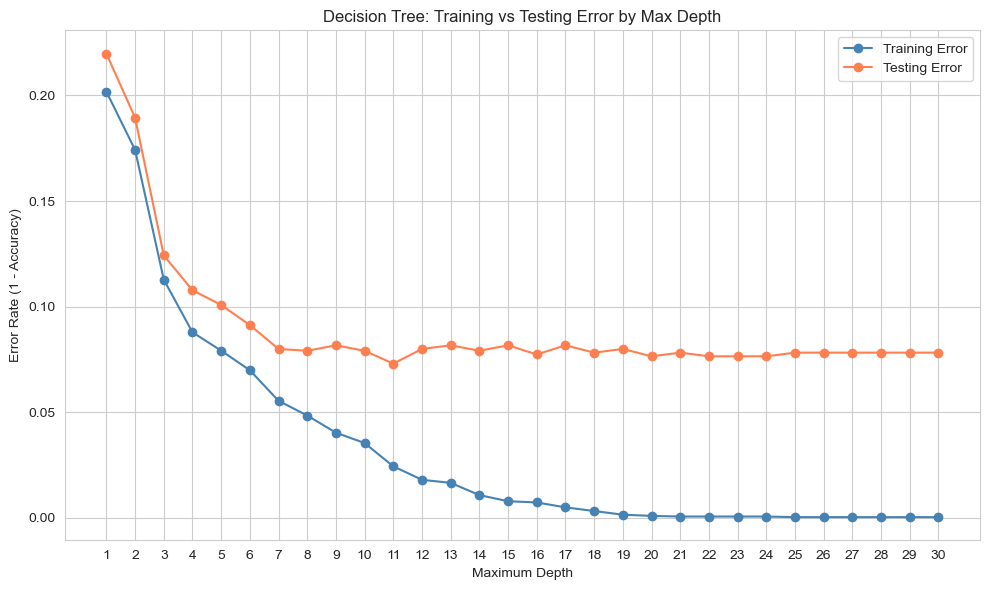

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(depths, train_errors, "o-", label="Training Error", color="steelblue")
plt.plot(depths, test_errors, "o-", label="Testing Error", color="coral")
plt.xlabel("Maximum Depth")
plt.ylabel("Error Rate (1 - Accuracy)")
plt.title("Decision Tree: Training vs Testing Error by Max Depth")
plt.legend()
plt.xticks(list(depths))
plt.tight_layout()
plt.show()

In [20]:
# Find the optimal depth (minimum test error)
optimal_depth = depths[np.argmin(test_errors)]
print(f"Optimal max_depth: {optimal_depth}")
print(f"  Training Error at optimal depth: {train_errors[optimal_depth - 1]:.4f}")
print(f"  Testing Error at optimal depth:  {test_errors[optimal_depth - 1]:.4f}")

Optimal max_depth: 11
  Training Error at optimal depth: 0.0243
  Testing Error at optimal depth:  0.0730


### Observations:
The plot shows the classic bias-variance tradeoff. At shallow depths (1–3), both
errors are high (underfitting). As depth increases, both decrease until around
depth 8–11 where test error bottoms out at ~7.3%. Beyond that, training error
keeps falling toward zero while test error plateaus around 7.8%. The tree starts
memorizing noise rather than learning generalizable patterns. The optimal depth of 11 (test error 7.30%, training error 2.43%) gives better test performance than the unpruned tree (7.82%), showing that pruning acts as effective regularization. Based on this, I would recommend a max_depth of 11 for this dataset.

# Problem 2

In [21]:
# Random Forest with T ∈ {10, 50, 100, 500}
n_estimators_list = [10, 50, 100, 500]
rf_results = {}

for T in n_estimators_list:
    rf = RandomForestClassifier(
        n_estimators=T, criterion="entropy", random_state=42, n_jobs=-1
    )
    rf.fit(X_spam_train, y_spam_train)
    metrics = evaluate_model(rf, X_spam_train, y_spam_train, X_spam_test, y_spam_test)
    rf_results[T] = metrics

In [22]:
rf_df = pd.DataFrame(rf_results).T
rf_df.index.name = "n_estimators (T)"
print("Random Forest Metrics by Number of Trees")
print(rf_df.round(4).to_string())

Random Forest Metrics by Number of Trees
                  Train Accuracy  Test Accuracy  Train F1  Test F1  Train AUC  Test AUC
n_estimators (T)                                                                       
10                        0.9971         0.9427    0.9963   0.9255        1.0    0.9825
50                        0.9997         0.9540    0.9996   0.9406        1.0    0.9860
100                       0.9997         0.9540    0.9996   0.9404        1.0    0.9863
500                       0.9997         0.9522    0.9996   0.9380        1.0    0.9868


### How do the metrics change as T increases?
Test accuracy and F1 improve from T=10 to T=50 (94.27% → 95.40%), then plateau. T=100 and T=500 give nearly identical results. AUC continues to inch up slightly (0.9825 → 0.9868), showing marginal gains in probability ranking. Training metrics stay near perfect throughout. This is the diminishing returns property of bagging: more trees stabilize the ensemble, but beyond ~50–100 trees the benefit is minimal.

In [23]:
# Comparison with Decision Tree
comparison_rf_dt = pd.DataFrame({
    "Decision Tree (Entropy, Unpruned)": metrics_entropy,
    "Decision Tree (Optimal Depth)": evaluate_model(
        DecisionTreeClassifier(criterion="entropy", max_depth=optimal_depth, random_state=42)
            .fit(X_spam_train, y_spam_train),
        X_spam_train, y_spam_train, X_spam_test, y_spam_test
    ),
    "Random Forest (T=100)": rf_results[100],
})
print("Comparison: Decision Tree vs Random Forest")
print(comparison_rf_dt.round(4).to_string())

Comparison: Decision Tree vs Random Forest
                Decision Tree (Entropy, Unpruned)  Decision Tree (Optimal Depth)  Random Forest (T=100)
Train Accuracy                             0.9997                         0.9757                 0.9997
Test Accuracy                              0.9218                         0.9270                 0.9540
Train F1                                   0.9996                         0.9685                 0.9996
Test F1                                    0.9015                         0.9056                 0.9404
Train AUC                                  1.0000                         0.9974                 1.0000
Test AUC                                   0.9193                         0.9358                 0.9863


### Observations:
Random Forest (T=100) outperforms both decision trees on every test metric. Test accuracy goes from 92.18% (unpruned) → 92.70% (pruned, depth=11) → 95.40% (RF). The AUC jump is 0.919 → 0.936 → 0.986, meaning RF produces much better probability rankings. Pruning helps the single tree slightly, but ensembling 100 decorrelated trees provides a far bigger gain. Bagging reduces variance without sacrificing the expressiveness of each individual tree.

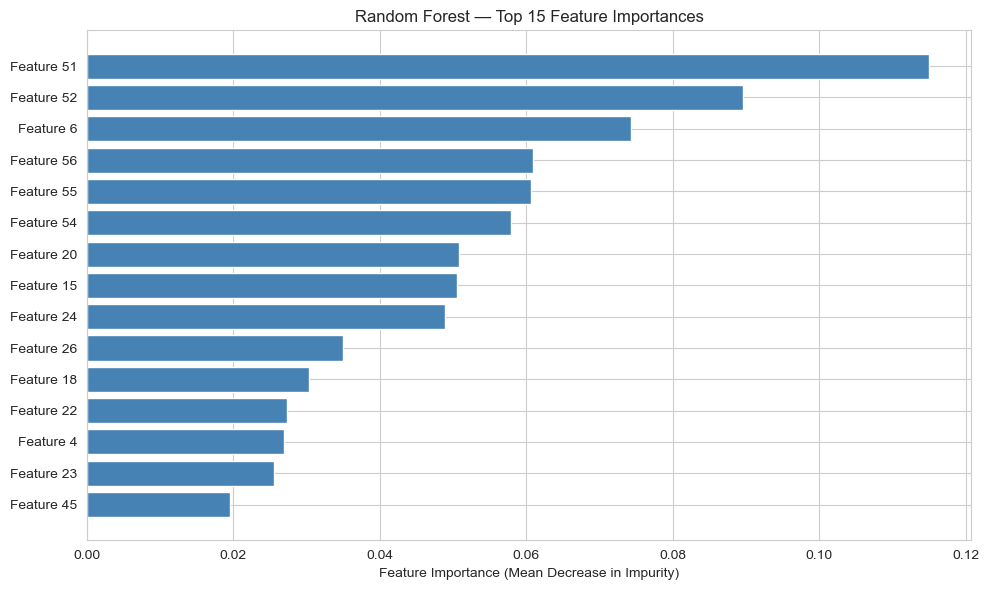

In [24]:
# Feature Importance
rf_100 = RandomForestClassifier(
    n_estimators=100, criterion="entropy", random_state=42, n_jobs=-1
)
rf_100.fit(X_spam_train, y_spam_train)

importances = rf_100.feature_importances_
feature_names = [f"Feature {i}" for i in range(X_spam.shape[1])]

# Sort by importance
sorted_idx = np.argsort(importances)[::-1]
top_n = 15  # Show top 15 features

plt.figure(figsize=(10, 6))
plt.barh(
    range(top_n),
    importances[sorted_idx[:top_n]][::-1],
    color="steelblue",
    edgecolor="white"
)
plt.yticks(range(top_n), [feature_names[i] for i in sorted_idx[:top_n]][::-1])
plt.xlabel("Feature Importance (Mean Decrease in Impurity)")
plt.title("Random Forest — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

In [26]:
# Print all feature importances sorted
print("All Feature Importances (sorted):")
for i in sorted_idx:
    print(f"  {feature_names[i]}: {importances[i]:.4f}")

All Feature Importances (sorted):
  Feature 51: 0.1150
  Feature 52: 0.0896
  Feature 6: 0.0742
  Feature 56: 0.0609
  Feature 55: 0.0607
  Feature 54: 0.0578
  Feature 20: 0.0508
  Feature 15: 0.0506
  Feature 24: 0.0489
  Feature 26: 0.0349
  Feature 18: 0.0303
  Feature 22: 0.0273
  Feature 4: 0.0269
  Feature 23: 0.0256
  Feature 45: 0.0196
  Feature 25: 0.0184
  Feature 11: 0.0156
  Feature 44: 0.0146
  Feature 49: 0.0145
  Feature 2: 0.0133
  Feature 36: 0.0132
  Feature 7: 0.0124
  Feature 9: 0.0105
  Feature 16: 0.0103
  Feature 5: 0.0090
  Feature 17: 0.0086
  Feature 27: 0.0064
  Feature 41: 0.0061
  Feature 10: 0.0052
  Feature 48: 0.0051
  Feature 34: 0.0048
  Feature 19: 0.0046
  Feature 0: 0.0042
  Feature 8: 0.0040
  Feature 38: 0.0039
  Feature 12: 0.0039
  Feature 1: 0.0039
  Feature 53: 0.0038
  Feature 35: 0.0037
  Feature 28: 0.0037
  Feature 29: 0.0033
  Feature 32: 0.0029
  Feature 50: 0.0023
  Feature 43: 0.0022
  Feature 30: 0.0017
  Feature 13: 0.0015
  Feature

### Observations:
Features 51 and 52 (capital letter run statistics) dominate, followed by Feature 6 (word frequency for a common spam keyword). Features 54–56 correspond to capital letter sequence metrics (total, longest, average), confirming that excessive capitalization is a strong spam signal. The importance drops off gradually, with many word-frequency features contributing moderate amounts and some features near zero. This suggests a relatively distributed signal where a handful of features carry the most weight but many others still contribute.

# Problem 3

In [27]:
# AdaBoost with T ∈ {10, 50, 100, 500}
ada_results = {}

for T in n_estimators_list:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=T,
        learning_rate=1.0,
        random_state=42,
        algorithm="SAMME"
    )
    ada.fit(X_spam_train, y_spam_train)
    metrics = evaluate_model(ada, X_spam_train, y_spam_train, X_spam_test, y_spam_test)
    ada_results[T] = metrics

In [28]:
ada_df = pd.DataFrame(ada_results).T
ada_df.index.name = "n_estimators (T)"
print("AdaBoost Metrics by Number of Base Classifiers")
print(ada_df.round(4).to_string())

AdaBoost Metrics by Number of Base Classifiers
                  Train Accuracy  Test Accuracy  Train F1  Test F1  Train AUC  Test AUC
n_estimators (T)                                                                       
10                        0.9058         0.8914    0.8807   0.8616     0.9638    0.9545
50                        0.9348         0.9209    0.9156   0.8976     0.9814    0.9762
100                       0.9414         0.9314    0.9247   0.9117     0.9843    0.9789
500                       0.9522         0.9374    0.9387   0.9195     0.9902    0.9828


In [29]:
# Comparison: AdaBoost vs Random Forest
comparison_data = {}
for T in n_estimators_list:
    comparison_data[f"RF (T={T})"] = rf_results[T]
    comparison_data[f"AdaBoost (T={T})"] = ada_results[T]

comparison_ensemble = pd.DataFrame(comparison_data)
print("Random Forest vs AdaBoost — Side by Side")
print(comparison_ensemble.round(4).to_string())

Random Forest vs AdaBoost — Side by Side
                RF (T=10)  AdaBoost (T=10)  RF (T=50)  AdaBoost (T=50)  RF (T=100)  AdaBoost (T=100)  RF (T=500)  AdaBoost (T=500)
Train Accuracy     0.9971           0.9058     0.9997           0.9348      0.9997            0.9414      0.9997            0.9522
Test Accuracy      0.9427           0.8914     0.9540           0.9209      0.9540            0.9314      0.9522            0.9374
Train F1           0.9963           0.8807     0.9996           0.9156      0.9996            0.9247      0.9996            0.9387
Test F1            0.9255           0.8616     0.9406           0.8976      0.9404            0.9117      0.9380            0.9195
Train AUC          1.0000           0.9638     1.0000           0.9814      1.0000            0.9843      1.0000            0.9902
Test AUC           0.9825           0.9545     0.9860           0.9762      0.9863            0.9789      0.9868            0.9828


### Observations:
Random Forest outperforms AdaBoost at every value of T. At T=100, RF achieves 95.40% test accuracy vs AdaBoost's 93.14%, and RF's test AUC (0.986) is consistently higher than AdaBoost's (0.979). The gap is largest at small T: RF with just 10 trees (94.27%) already beats AdaBoost with 100 stumps (93.14%). This reflects the fundamental difference in their strategies. RF uses full trees (strong learners) and reduces variance through bagging, so even a small ensemble is effective. AdaBoost uses depth-1 stumps (weak learners) and builds power sequentially, so it needs more iterations to reach competitive performance. AdaBoost's training accuracy also grows gradually (90.58% to 95.22%), while RF is near-perfect from the start. Both ensembles improve with more base learners, but AdaBoost benefits more from additional iterations since each new stump corrects previous mistakes.

In [30]:
# ROC Curves: Decision Tree vs RF(100) vs AdaBoost(100)

# Get the models
dt_for_roc = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_for_roc.fit(X_spam_train, y_spam_train)

rf_for_roc = RandomForestClassifier(
    n_estimators=100, criterion="entropy", random_state=42, n_jobs=-1
)
rf_for_roc.fit(X_spam_train, y_spam_train)

ada_for_roc = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42,
    algorithm="SAMME"
)
ada_for_roc.fit(X_spam_train, y_spam_train)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=100, random_state=42)

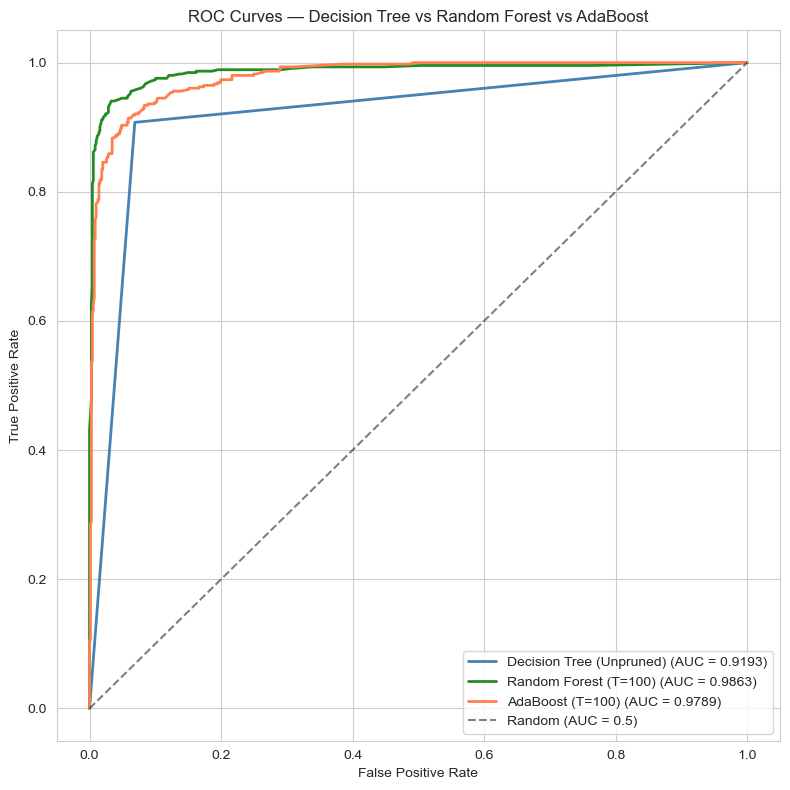

In [31]:
plt.figure(figsize=(8, 8))

models = [
    ("Decision Tree (Unpruned)", dt_for_roc, "steelblue"),
    ("Random Forest (T=100)", rf_for_roc, "forestgreen"),
    ("AdaBoost (T=100)", ada_for_roc, "coral"),
]

for name, model, color in models:
    y_proba = model.predict_proba(X_spam_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_spam_test, y_proba)
    auc_val = roc_auc_score(y_spam_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})", color=color, linewidth=2)

plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Decision Tree vs Random Forest vs AdaBoost")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Problem 4

In [32]:
# Load the Mushroom dataset
mushroom_df = pd.read_csv("mushroom/agaricus-lepiota.data", header=None)

# Separate features and labels
y_mushroom_raw = mushroom_df.iloc[:, 0].values
X_mushroom_raw = mushroom_df.iloc[:, 1:].values  

print(f"Mushroom dataset: {X_mushroom_raw.shape[0]} samples, {X_mushroom_raw.shape[1]} features")
print(f"Class distribution: {pd.Series(y_mushroom_raw).value_counts().to_dict()}")

Mushroom dataset: 8124 samples, 22 features
Class distribution: {'e': 4208, 'p': 3916}


In [33]:
# Train/test split (75/25)
X_mush_train, X_mush_test, y_mush_train, y_mush_test = train_test_split(
    X_mushroom_raw, y_mushroom_raw, test_size=0.25, random_state=42, stratify=y_mushroom_raw
)

print(f"Train: {X_mush_train.shape[0]}, Test: {X_mush_test.shape[0]}")

Train: 6093, Test: 2031


In [34]:
# From-Scratch Naive Bayes with Laplace Smoothing
class NaiveBayesCategorical:
    """
    Naive Bayes classifier for categorical features with Laplace smoothing.

    Training:
      - Compute prior P(Y=y) for each class
      - For each feature i and class y, compute P(X_i=x | Y=y) with Laplace smoothing

    Prediction:
      - For each test point, compute log P(Y=y) + sum of log P(X_i | Y=y)
      - Assign the class with the highest log-posterior
    """

    def __init__(self, alpha=1):
        """
        Parameters
        ----------
        alpha : float
            Laplace smoothing parameter (1 = standard Laplace smoothing).
        """
        self.alpha = alpha
        self.classes_ = None
        self.priors_ = None           # dict: class -> log P(Y=class)
        self.likelihoods_ = None      # dict: (feature_idx, class) -> {value: log P(X_i=value|Y=class)}
        self.feature_vocabs_ = None   # dict: feature_idx -> set of all possible values
        self.class_counts_ = None     # dict: class -> number of training samples in that class

    def fit(self, X, y):
        """Train the Naive Bayes classifier by computing priors and likelihoods."""
        self.classes_ = np.unique(y)
        n = len(y)

        # Priors 
        self.priors_ = {}
        self.class_counts_ = {}
        for c in self.classes_:
            count_c = np.sum(y == c)
            self.class_counts_[c] = count_c
            self.priors_[c] = np.log(count_c / n)

        # Feature vocabularies (all unique values per feature)
        self.feature_vocabs_ = {}
        n_features = X.shape[1]
        for j in range(n_features):
            self.feature_vocabs_[j] = set(np.unique(X[:, j]))

        # Likelihoods with Laplace smoothing
        self.likelihoods_ = {}
        for j in range(n_features):
            vocab_size = len(self.feature_vocabs_[j])
            for c in self.classes_:
                # Get feature values for this class
                X_c = X[y == c, j]
                total_count = len(X_c)

                # Count each value and apply Laplace smoothing
                value_probs = {}
                for val in self.feature_vocabs_[j]:
                    count_val = np.sum(X_c == val)
                    value_probs[val] = np.log((count_val + self.alpha) / (total_count + self.alpha * vocab_size))

                self.likelihoods_[(j, c)] = value_probs

        return self

    def predict_log_proba(self, X):
        """
        Compute log P(Y=y|X) (up to a constant) for each class.

        Returns
        -------
        log_proba : ndarray of shape (n_samples, n_classes)
        """
        n_samples = X.shape[0]
        n_features = X.shape[1]
        log_proba = np.zeros((n_samples, len(self.classes_)))

        for idx, c in enumerate(self.classes_):
            # Start with the log prior
            log_proba[:, idx] = self.priors_[c]

            # Add log-likelihoods for each feature
            for j in range(n_features):
                value_probs = self.likelihoods_[(j, c)]
                vocab_size = len(self.feature_vocabs_[j])
                
                # For unseen values: Laplace smoothed with count = 0
                n_c = self.class_counts_[c]
                default_log_prob = np.log(self.alpha / (n_c + self.alpha * vocab_size))

                for i in range(n_samples):
                    val = X[i, j]
                    if val in value_probs:
                        log_proba[i, idx] += value_probs[val]
                    else:
                        log_proba[i, idx] += default_log_prob

        return log_proba

    def predict(self, X):
        """Predict class labels for samples in X."""
        log_proba = self.predict_log_proba(X)
        return self.classes_[np.argmax(log_proba, axis=1)]

    def predict_proba(self, X):
        """
        Predict class probabilities (normalized from log-posteriors).

        Returns
        -------
        proba : ndarray of shape (n_samples, n_classes)
        """
        log_proba = self.predict_log_proba(X)
        # Normalize using log-sum-exp for numerical stability
        log_sum = np.log(np.sum(np.exp(log_proba - log_proba.max(axis=1, keepdims=True)), axis=1, keepdims=True))
        log_proba_normalized = log_proba - log_proba.max(axis=1, keepdims=True) - log_sum
        return np.exp(log_proba_normalized)

In [35]:
# Train our from-scratch Naive Bayes
nb_scratch = NaiveBayesCategorical(alpha=1)
nb_scratch.fit(X_mush_train, y_mush_train)

In [42]:
# Print prior probabilities
print("Prior Probabilities:")
for c in nb_scratch.classes_:
    label = "Edible" if c == "e" else "Poisonous"
    print(f"  P(Y={label}) = {np.exp(nb_scratch.priors_[c]):.4f}")

Prior Probabilities:
  P(Y=Edible) = 0.5180
  P(Y=Poisonous) = 0.4820


In [43]:
# Print conditional probabilities for all features
n_features = X_mush_train.shape[1]
print("\nConditional Probabilities P(X_i = x | Y) for All Features:")
for j in range(n_features):
    print(f"\n  Feature {j}:")
    for c in nb_scratch.classes_:
        label = "Edible" if c == "e" else "Poisonous"
        probs = nb_scratch.likelihoods_[(j, c)]
        prob_str = ", ".join(f"P({v}|{label})={np.exp(p):.4f}" for v, p in sorted(probs.items()))
        print(f"    {prob_str}")


Conditional Probabilities P(X_i = x | Y) for All Features:

  Feature 0:
    P(b|Edible)=0.0936, P(c|Edible)=0.0003, P(f|Edible)=0.3751, P(k|Edible)=0.0547, P(s|Edible)=0.0079, P(x|Edible)=0.4684
    P(b|Poisonous)=0.0129, P(c|Poisonous)=0.0017, P(f|Poisonous)=0.3955, P(k|Poisonous)=0.1485, P(s|Poisonous)=0.0003, P(x|Poisonous)=0.4410

  Feature 1:
    P(f|Edible)=0.3722, P(g|Edible)=0.0003, P(s|Edible)=0.2766, P(y|Edible)=0.3509
    P(f|Poisonous)=0.2016, P(g|Poisonous)=0.0014, P(s|Poisonous)=0.3611, P(y|Poisonous)=0.4359

  Feature 2:
    P(b|Edible)=0.0114, P(c|Edible)=0.0082, P(e|Edible)=0.1459, P(g|Edible)=0.2486, P(n|Edible)=0.3023, P(p|Edible)=0.0133, P(r|Edible)=0.0047, P(u|Edible)=0.0035, P(w|Edible)=0.1646, P(y|Edible)=0.0976
    P(b|Poisonous)=0.0299, P(c|Poisonous)=0.0031, P(e|Poisonous)=0.2182, P(g|Poisonous)=0.2124, P(n|Poisonous)=0.2548, P(p|Poisonous)=0.0241, P(r|Poisonous)=0.0003, P(u|Poisonous)=0.0003, P(w|Poisonous)=0.0838, P(y|Poisonous)=0.1731

  Feature 3:
    P(

In [39]:
# Predict Class Probabilities on the Test Set

# Predict on test set
y_mush_pred_scratch = nb_scratch.predict(X_mush_test)
proba_scratch = nb_scratch.predict_proba(X_mush_test)

# Display predicted probabilities for all test points
e_idx = list(nb_scratch.classes_).index("e")
p_idx = list(nb_scratch.classes_).index("p")

proba_df = pd.DataFrame({
    "Actual": y_mush_test,
    "Predicted": y_mush_pred_scratch,
    "P(Edible)": proba_scratch[:, e_idx],
    "P(Poisonous)": proba_scratch[:, p_idx],
})
print(f"Test Set Predictions ({len(y_mush_test)} samples):")
print(proba_df.to_string())

Test Set Predictions (2031 samples):
     Actual Predicted     P(Edible)  P(Poisonous)
0         e         e  1.000000e+00  3.600629e-08
1         p         p  3.864316e-10  1.000000e+00
2         e         e  9.999970e-01  2.982959e-06
3         p         e  9.794624e-01  2.053762e-02
4         p         p  7.960977e-13  1.000000e+00
5         e         e  9.999948e-01  5.199634e-06
6         p         p  1.921995e-12  1.000000e+00
7         p         p  1.157036e-09  1.000000e+00
8         e         e  1.000000e+00  1.554688e-09
9         p         e  7.316793e-01  2.683207e-01
10        e         e  1.000000e+00  3.023151e-08
11        e         e  1.000000e+00  4.022922e-11
12        e         e  1.000000e+00  1.551886e-09
13        e         e  1.000000e+00  9.150779e-09
14        p         e  9.748510e-01  2.514896e-02
15        p         p  5.856102e-14  1.000000e+00
16        e         e  1.000000e+00  3.527492e-08
17        p         p  3.479629e-13  1.000000e+00
18        p  

In [40]:
# Evaluation Metrics (From-Scratch NB)

# Compute Metrics
accuracy_scratch = accuracy_score(y_mush_test, y_mush_pred_scratch)
precision_scratch = precision_score(y_mush_test, y_mush_pred_scratch, pos_label="p")
recall_scratch = recall_score(y_mush_test, y_mush_pred_scratch, pos_label="p")
f1_scratch = f1_score(y_mush_test, y_mush_pred_scratch, pos_label="p")

print("From-Scratch Naive Bayes — Test Metrics")
print("-" * 40)
print(f"  Accuracy:  {accuracy_scratch:.4f}")
print(f"  Precision: {precision_scratch:.4f}")
print(f"  Recall:    {recall_scratch:.4f}")
print(f"  F1 Score:  {f1_scratch:.4f}")

From-Scratch Naive Bayes — Test Metrics
----------------------------------------
  Accuracy:  0.9527
  Precision: 0.9911
  Recall:    0.9101
  F1 Score:  0.9489


In [44]:
# Comparison with sklearn's Naive Bayes
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_mush_train_enc = encoder.fit_transform(X_mush_train)
X_mush_test_enc = encoder.transform(X_mush_test)

# Train sklearn NB
nb_sklearn = CategoricalNB(alpha=1.0)
nb_sklearn.fit(X_mush_train_enc, y_mush_train)

y_mush_pred_sklearn = nb_sklearn.predict(X_mush_test_enc)

In [ ]:
# Compute metrics for sklearn
accuracy_sklearn = accuracy_score(y_mush_test, y_mush_pred_sklearn)
precision_sklearn = precision_score(y_mush_test, y_mush_pred_sklearn, pos_label="p")
recall_sklearn = recall_score(y_mush_test, y_mush_pred_sklearn, pos_label="p")
f1_sklearn = f1_score(y_mush_test, y_mush_pred_sklearn, pos_label="p")

In [46]:
# Side-by-side comparison
comparison_nb = pd.DataFrame({
    "From-Scratch NB": {
        "Accuracy": accuracy_scratch,
        "Precision": precision_scratch,
        "Recall": recall_scratch,
        "F1 Score": f1_scratch,
    },
    "sklearn CategoricalNB": {
        "Accuracy": accuracy_sklearn,
        "Precision": precision_sklearn,
        "Recall": recall_sklearn,
        "F1 Score": f1_sklearn,
    },
})
print("Comparison: From-Scratch vs sklearn Naive Bayes")
print(comparison_nb.round(4).to_string())

Comparison: From-Scratch vs sklearn Naive Bayes
           From-Scratch NB  sklearn CategoricalNB
Accuracy            0.9527                 0.9527
Precision           0.9911                 0.9911
Recall              0.9101                 0.9101
F1 Score            0.9489                 0.9489


### Observations:
The from-scratch and sklearn implementations produce identical results across all four metrics (95.27% accuracy, 0.991 precision, 0.910 recall, 0.949 F1). This confirms our implementation correctly computes the priors, conditional probabilities, and Laplace smoothing. The high precision (99.1%) means when the model predicts poisonous, it is almost always correct. Recall is slightly lower (91.0%), meaning some poisonous mushrooms are misclassified as edible.